# 04 — Exploratory Population and Robustness Validation

This notebook tests whether the selected pre-call models remain useful outside a conventional shuffled split. It is self-contained, reads only `term-deposit-marketing-2020-labelled.csv`, writes no result files, and excludes `duration` throughout.

The analyses are deliberately separated into: exploratory-population validation with default models, shuffled validation, pseudo-profile grouped sensitivity, and expanding-window ordered validation.

## 1. Setup and canonical pre-call settings

The fresh Notebook-02 tuned, unweighted pre-call settings are transferred without retuning. The ordered analysis therefore tests robustness of the already-selected model structures rather than creating a new search problem.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold,StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,average_precision_score,brier_score_loss
warnings.filterwarnings("ignore")
SEED=42; DATA_SOURCE="term-deposit-marketing-2020-labelled.csv"
NUM=["age","balance","day","campaign"]; CAT=["job","marital","education","default","housing","loan","contact","month"]; PRE=NUM+CAT; PROFILE=["age","job","marital","education","balance"]
TUNED={"LR":{"C":8.483428982440726,"penalty":"l2","class_weight":None},"HGB":{"max_iter":200,"max_depth":8,"learning_rate":0.05,"max_leaf_nodes":15,"l2_regularization":0.0,"min_samples_leaf":20,"class_weight":None,"early_stopping":True}}
df=pd.read_csv(DATA_SOURCE)
if "y_binary" in df.columns: df=df.drop(columns="y_binary")
df["y_binary"]=df["y"].eq("yes").astype(int); y=df["y_binary"].to_numpy(); assert "duration" not in PRE
print("Canonical source shape:",df.drop(columns="y_binary").shape); print("Base subscription rate:",round(df.y_binary.mean(),6)); print("Duration in deployable predictors:","duration" in PRE)

Canonical source shape: (40000, 14)
Base subscription rate: 0.0724
Duration in deployable predictors: False


### 1.1 Model construction and scoring

The same preprocessing and metric definitions are used for every robustness comparison. Default models are reserved for the exploratory population; tuned models are used for shuffled, grouped and ordered robustness tests.

In [2]:
def preprocessor(features=PRE):
    return ColumnTransformer([("numeric",StandardScaler(),[f for f in features if f in NUM]),("categorical",OneHotEncoder(handle_unknown="ignore",sparse_output=False),[f for f in features if f in CAT])])
def default_model(kind):
    if kind=="LR": return LogisticRegression(C=1.0,penalty="l2",solver="lbfgs",max_iter=1000,tol=1e-4,class_weight=None,random_state=SEED)
    return HistGradientBoostingClassifier(loss="log_loss",learning_rate=.1,max_iter=100,max_leaf_nodes=31,max_depth=None,min_samples_leaf=20,l2_regularization=0,max_bins=255,early_stopping="auto",class_weight=None,random_state=SEED)
def tuned_model(kind):
    return LogisticRegression(solver="liblinear",max_iter=3000,random_state=SEED,**TUNED["LR"]) if kind=="LR" else HistGradientBoostingClassifier(random_state=SEED,**TUNED["HGB"])
def pipeline(kind,tuned=True,features=PRE): return Pipeline([("preprocess",preprocessor(features)),("model",tuned_model(kind) if tuned else default_model(kind))])
def score_metrics(yt,p,threshold=.5):
    z=(np.asarray(p)>=threshold).astype(int); return {"n_rows":len(yt),"base_rate":float(np.mean(yt)),"accuracy":accuracy_score(yt,z),"precision":precision_score(yt,z,zero_division=0),"recall":recall_score(yt,z,zero_division=0),"f1":f1_score(yt,z,zero_division=0),"pr_auc":average_precision_score(yt,p),"roc_auc":roc_auc_score(yt,p),"brier":brier_score_loss(yt,p)}
def six_metric_panel(table,labels,title):
    ms=["accuracy","precision","recall","f1","pr_auc","roc_auc"]; fig,axes=plt.subplots(2,3,figsize=(15,8)); axes=axes.ravel(); z=table.copy(); z["_label"]=labels
    for ax,m in zip(axes,ms): ax.bar(z._label,z[m]); ax.set_title(m.replace("_"," ").upper()); ax.tick_params(axis="x",rotation=35); ax.grid(axis="y",alpha=.25)
    fig.suptitle(title,y=1.02); fig.tight_layout(); plt.show()

## 2. Exploratory higher-conversion population

The descriptive rule is `contact = cellular AND (job = retired OR age ≥ 71 OR balance ≥ Q3)`. The full-data Q3 is shown only to describe the population. During validation the balance threshold is learned inside each training fold.

This population uses **untuned/default models only**. There is no subgroup retuning and no tuned-transfer result.

In [3]:
full_q3=float(df.balance.quantile(.75)); full_segment=df.contact.eq("cellular")&(df.job.eq("retired")|df.age.ge(71)|df.balance.ge(full_q3))
segment_summary=pd.DataFrame([{"customers":int(full_segment.sum()),"subscribers":int(df.loc[full_segment,"y_binary"].sum()),"subscription_rate":float(df.loc[full_segment,"y_binary"].mean()),"balance_q3_full_data":full_q3,"age_cutoff":71}]); display(segment_summary.round(6))

,customers,subscribers,subscription_rate,balance_q3_full_data,age_cutoff
0,6774,778,0.114851,1319.0,71


### 2.1 Population model validation

The segment balance threshold is learned inside each training fold before being applied to the corresponding validation rows, preventing full-sample threshold leakage.

,model,stage,n_rows,base_rate,accuracy,precision,recall,f1,pr_auc,roc_auc,brier
0,LR,Untuned/default only,6772,0.114885,0.883934,0.420000,0.026992,0.050725,0.286349,0.692504,0.092816
1,HGB,Untuned/default only,6772,0.114885,0.884968,0.497537,0.129820,0.205912,0.303476,0.694120,0.092533


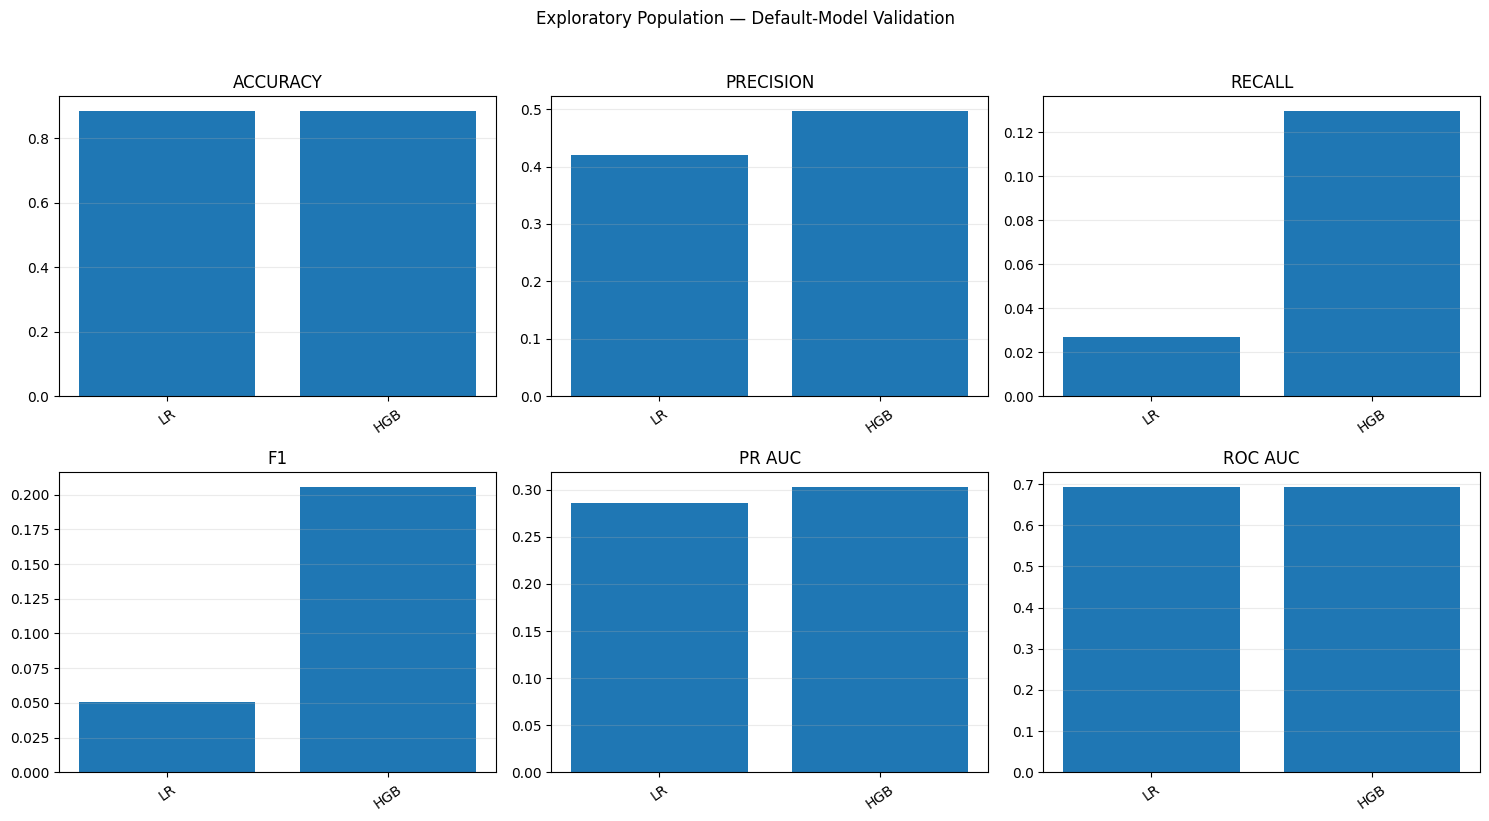

In [4]:
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED); segment_rows=[]
for kind in ["LR","HGB"]:
    probs=[]; truths=[]
    for tr,va in skf.split(df[PRE],y):
        q3=float(df.iloc[tr].balance.quantile(.75)); st=df.iloc[tr].contact.eq("cellular")&(df.iloc[tr].job.eq("retired")|df.iloc[tr].age.ge(71)|df.iloc[tr].balance.ge(q3)); sv=df.iloc[va].contact.eq("cellular")&(df.iloc[va].job.eq("retired")|df.iloc[va].age.ge(71)|df.iloc[va].balance.ge(q3)); trr=tr[st.to_numpy()]; var=va[sv.to_numpy()]; est=pipeline(kind,tuned=False); est.fit(df.loc[trr,PRE],y[trr]); probs.append(est.predict_proba(df.loc[var,PRE])[:,1]); truths.append(y[var])
    p=np.concatenate(probs); yt=np.concatenate(truths); segment_rows.append({"model":kind,"stage":"Untuned/default only",**score_metrics(yt,p)})
segment_models=pd.DataFrame(segment_rows); display(segment_models.round(6)); six_metric_panel(segment_models,segment_models.model.tolist(),"Exploratory Population — Default-Model Validation")

## 3. Standard shuffled validation and pseudo-profile grouped sensitivity

The principal shuffled comparison uses stratified 5-fold validation. Because no true customer ID exists, a separate sensitivity test groups identical pseudo-profiles defined by `age + job + marital + education + balance`. This is **not** true customer-level validation.

,model,validation,n_rows,base_rate,accuracy,precision,recall,f1,pr_auc,roc_auc,brier
0,LR,row_stratified_5fold,40000,0.0724,0.927825,0.524590,0.033149,0.062358,0.215433,0.684767,0.062800
1,HGB,row_stratified_5fold,40000,0.0724,0.927450,0.486957,0.038674,0.071657,0.245333,0.717461,0.060778


,model,validation,n_rows,base_rate,accuracy,precision,recall,f1,pr_auc,roc_auc,brier
0,LR,pseudo_group_5fold_sensitivity,40000,0.0724,0.927725,0.513514,0.032804,0.061668,0.215690,0.685003,0.062797
1,HGB,pseudo_group_5fold_sensitivity,40000,0.0724,0.928100,0.544643,0.042127,0.078205,0.248093,0.716737,0.060719


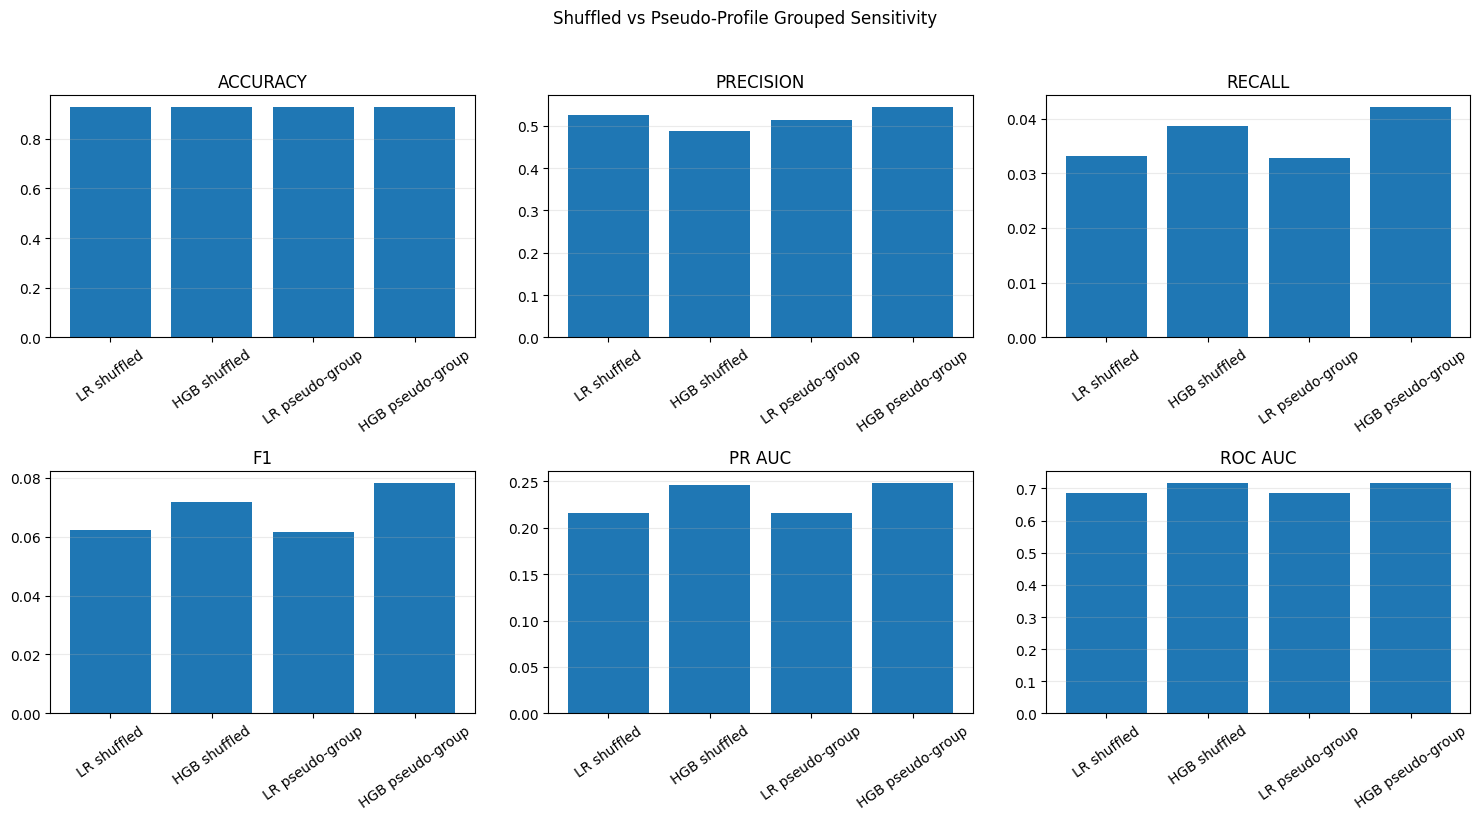

In [5]:
def cv_predictions(kind,splitter,groups=None):
    oof=np.zeros(len(df)); args=(df[PRE],y) if groups is None else (df[PRE],y,groups)
    for tr,va in splitter.split(*args):
        est=pipeline(kind,tuned=True); est.fit(df.loc[tr,PRE],y[tr]); oof[va]=est.predict_proba(df.loc[va,PRE])[:,1]
    return oof
shuffled_rows=[]
for kind in ["LR","HGB"]: p=cv_predictions(kind,StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)); shuffled_rows.append({"model":kind,"validation":"row_stratified_5fold",**score_metrics(y,p)})
shuffled=pd.DataFrame(shuffled_rows); pseudo_id=df.groupby(PROFILE,dropna=False,sort=False).ngroup().to_numpy(); grouped_rows=[]
for kind in ["LR","HGB"]: p=cv_predictions(kind,StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=SEED),pseudo_id); grouped_rows.append({"model":kind,"validation":"pseudo_group_5fold_sensitivity",**score_metrics(y,p)})
grouped=pd.DataFrame(grouped_rows); display(shuffled.round(6)); display(grouped.round(6)); comp=pd.concat([shuffled.assign(label=shuffled.model+" shuffled"),grouped.assign(label=grouped.model+" pseudo-group")],ignore_index=True); six_metric_panel(comp,comp.label.tolist(),"Shuffled vs Pseudo-Profile Grouped Sensitivity")

## 4. Ordered month-labelled blocks and forward eligibility gate

A new block starts whenever the month label changes in source-row order. These are ordered month-labelled blocks, **not verified calendar years or campaign IDs**. A forward block is eligible only when at least 5,000 earlier rows and at least 100 positive and 100 negative test outcomes are available.

In [6]:
ordered=df.copy(); ordered["row_order"]=np.arange(len(ordered)); ordered["period_id"]=ordered.month.astype(str).ne(ordered.month.astype(str).shift()).cumsum()
gate=ordered.groupby("period_id").agg(month=("month","first"),start_row=("row_order","min"),test_n=("y_binary","size"),positives=("y_binary","sum")).reset_index(); gate["train_n"]=gate.start_row; gate["negatives"]=gate.test_n-gate.positives; gate["period_label"]=[f"P{int(p):02d}-{m}" for p,m in zip(gate.period_id,gate.month)]; gate["eligible"]=gate.train_n.ge(5000)&gate.positives.ge(100)&gate.negatives.ge(100); display(gate[["period_id","period_label","train_n","test_n","positives","negatives","eligible"]]); print("Eligible periods:",gate.loc[gate.eligible,"period_id"].astype(int).tolist())

,period_id,period_label,train_n,test_n,positives,negatives,eligible
0,1,P01-may,0,7957,258,7699,False
1,2,P02-jun,7957,4486,201,4285,True
2,3,P03-jul,12443,6380,384,5996,True
3,4,P04-aug,18823,5215,288,4927,True
4,5,P05-oct,24038,80,49,31,False
5,6,P06-nov,24118,3598,220,3378,True
6,7,P07-dec,27716,13,1,12,False
7,8,P08-jan,27729,1176,38,1138,False
8,9,P09-feb,28905,2296,255,2041,True
9,10,P10-mar,31201,258,125,133,True


Eligible periods: [2, 3, 4, 6, 9, 10, 11, 12]


## 5. Expanding-window ordered validation

For every eligible block, each tuned unweighted model is refitted on **all earlier rows only** and scored on the next eligible block. No forward-period retuning is performed.

In [7]:
forward_rows=[]
for _,period in gate.loc[gate.eligible].iterrows():
    pid=int(period.period_id); tr=ordered.index[ordered.period_id<pid].to_numpy(); te=ordered.index[ordered.period_id==pid].to_numpy()
    for kind in ["LR","HGB"]:
        est=pipeline(kind,tuned=True); est.fit(df.loc[tr,PRE],y[tr]); p=est.predict_proba(df.loc[te,PRE])[:,1]; forward_rows.append({"model":kind,"period_id":pid,"period_label":period.period_label,"train_n":len(tr),"test_n":len(te),"positives":int(y[te].sum()),**score_metrics(y[te],p)})
forward_periods=pd.DataFrame(forward_rows); display(forward_periods[["model","period_id","period_label","train_n","test_n","positives","roc_auc","pr_auc","brier"]].round(6))

,model,period_id,period_label,train_n,test_n,positives,roc_auc,pr_auc,brier
0,LR,2,P02-jun,7957,4486,201,0.563847,0.056549,0.042875
1,HGB,2,P02-jun,7957,4486,201,0.532760,0.050645,0.043026
2,LR,3,P03-jul,12443,6380,384,0.560581,0.074960,0.058494
3,HGB,3,P03-jul,12443,6380,384,0.560953,0.070856,0.057397
4,LR,4,P04-aug,18823,5215,288,0.533949,0.067711,0.052632
5,HGB,4,P04-aug,18823,5215,288,0.564300,0.073019,0.052071
6,LR,6,P06-nov,24118,3598,220,0.530716,0.067605,0.062714
7,HGB,6,P06-nov,24118,3598,220,0.504602,0.061484,0.057705
8,LR,9,P09-feb,28905,2296,255,0.512019,0.115945,0.099639
9,HGB,9,P09-feb,28905,2296,255,0.540685,0.122069,0.101098


### 5.1 Aggregate forward performance

Eligible blocks differ greatly in size, so weighted ROC-AUC, PR-AUC and Brier are the headline ordered metrics. The period line plot also shows how discrimination changes from one eligible block to the next.

,model,periods,test_rows,test_positives,roc_auc_weighted,pr_auc_weighted,brier_weighted
0,HGB,8,30526,2457,0.55160,0.096333,0.074181
1,LR,8,30526,2457,0.56629,0.112626,0.074776


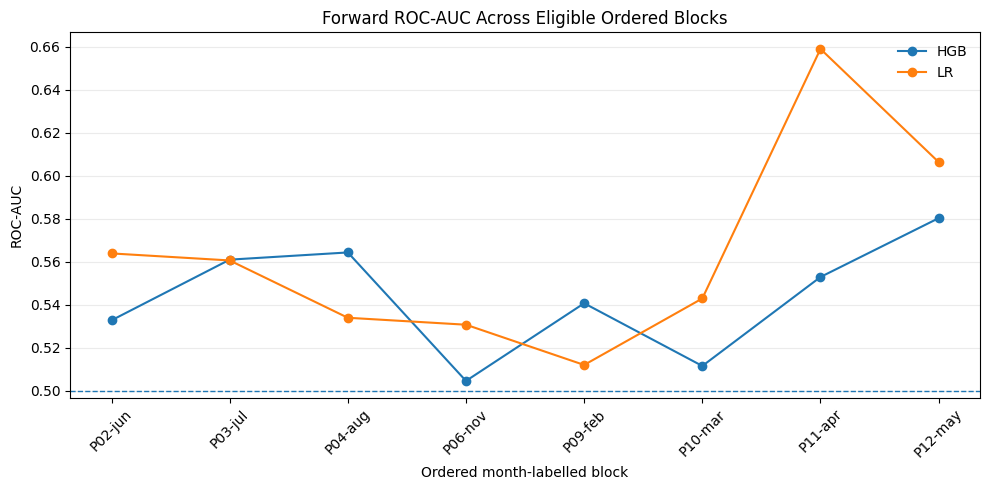

In [8]:
summary=[]
for kind,d in forward_periods.groupby("model"):
    w=d.test_n.to_numpy(float); w=w/w.sum(); rw=float(np.sum(w*d.roc_auc)); pw=float(np.sum(w*d.pr_auc)); bw=float(np.sum(w*d.brier)); summary.append({"model":kind,"periods":len(d),"test_rows":int(d.test_n.sum()),"test_positives":int(d.positives.sum()),"roc_auc_weighted":rw,"pr_auc_weighted":pw,"brier_weighted":bw})
ordered_summary=pd.DataFrame(summary).sort_values("model").reset_index(drop=True); display(ordered_summary.round(6))
fig,ax=plt.subplots(figsize=(10,5))
for kind,d in forward_periods.groupby("model"): d=d.sort_values("period_id"); ax.plot(d.period_label,d.roc_auc,marker="o",label=kind)
ax.axhline(.5,linestyle="--",linewidth=1); ax.set_ylabel("ROC-AUC"); ax.set_xlabel("Ordered month-labelled block"); ax.set_title("Forward ROC-AUC Across Eligible Ordered Blocks"); ax.tick_params(axis="x",rotation=45); ax.legend(frameon=False); ax.grid(axis="y",alpha=.25); fig.tight_layout(); plt.show()

## 6. Shuffled versus ordered robustness

This is the key model-selection robustness check: HGB is stronger under shuffled historical validation, while LR is stronger once the data are evaluated in forward source order. The simple comparison below is intended for direct report use.

,model,validation,roc_auc,pr_auc
0,LR,Shuffled 5-fold,0.684767,0.215433
1,HGB,Shuffled 5-fold,0.717461,0.245333
2,HGB,Ordered expanding-window,0.551600,0.096333
3,LR,Ordered expanding-window,0.566290,0.112626


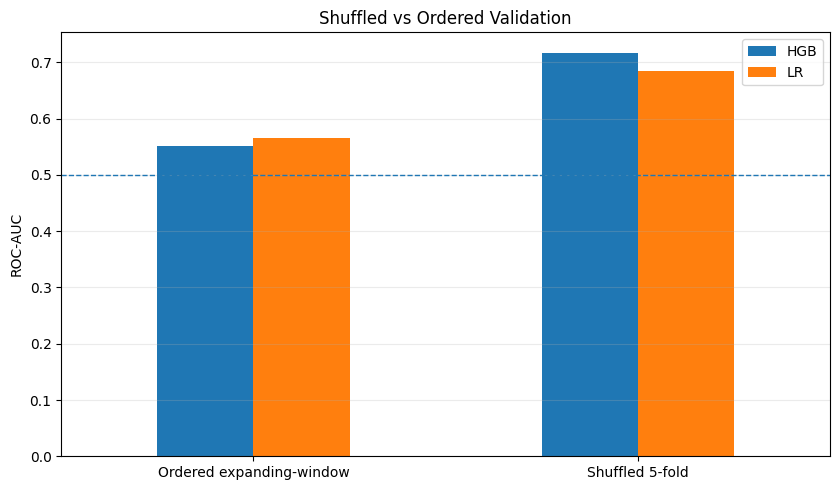

In [9]:
validation_comparison=pd.DataFrame([{"model":r.model,"validation":"Shuffled 5-fold","roc_auc":r.roc_auc,"pr_auc":r.pr_auc} for _,r in shuffled.iterrows()]+[{"model":r.model,"validation":"Ordered expanding-window","roc_auc":r.roc_auc_weighted,"pr_auc":r.pr_auc_weighted} for _,r in ordered_summary.iterrows()]); display(validation_comparison.round(6)); ax=validation_comparison.pivot(index="validation",columns="model",values="roc_auc").plot(kind="bar",figsize=(8.5,5)); ax.axhline(.5,linestyle="--",linewidth=1); ax.set_ylabel("ROC-AUC"); ax.set_xlabel(""); ax.set_title("Shuffled vs Ordered Validation"); ax.tick_params(axis="x",rotation=0); ax.legend(title=""); ax.grid(axis="y",alpha=.25); plt.tight_layout(); plt.show()

## 7. Notebook-04 conclusion

The exploratory population is descriptive and uses default models only. Shuffled and pseudo-profile grouped results are sensitivity checks; expanding-window ordered validation is the stricter robustness test. Ordered blocks are not verified years, and all modelling remains pre-call only.